In [106]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import numpy as np

## Task 1: Bisection Method

All root-finding methods are built on iterative procedures: one starts with a guess $x_0$ and uses some update rule to arrive at a new guess, iterating until convergence.

The simplest and most robust method is the **bisection method**. If there is a root between $[a, b]$ and $f(a)f(b) < 0$, we calculate the midpoint $c$, producing two sub-intervals $[a,c]$ and $[c,b]$, then pick the interval where the product of the function values is negative. This proceeds until the interval width is smaller than a chosen tolerance.

Source: Guide5

---
#### 1. Plot $\sin(\cosh(2x))$ on $[0, 1]$

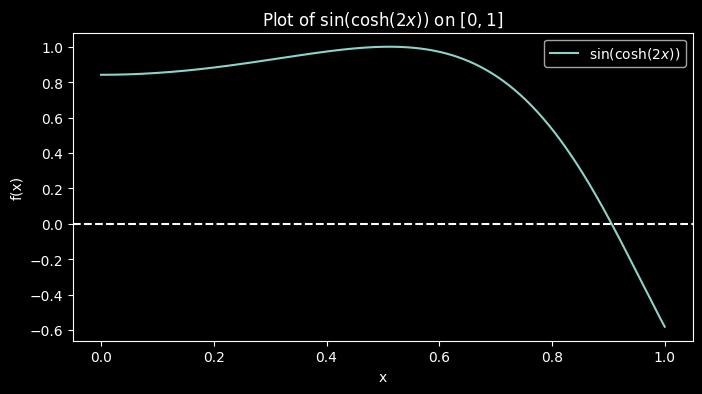

In [107]:
#1. 
x = np.linspace(0, 1, 500) # [0,1] with 500 points
f = np.sin(np.cosh(2 * x))

plt.figure(figsize=(8, 4))
plt.plot(x, f,label=r'$\sin(\cosh(2x))$')
plt.axhline(0,ls='--')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'Plot of $\sin(\cosh(2x))$ on $[0, 1]$')
plt.legend()

plt.show()

#### 2. Analysis: Does it have a root?

*ANS:* Yes. From the plot, the function starts positive near $x=0.8$ and dips below zero around $x \approx 0.9$–$0.95$. So there is 1 root in [0,1] where the function crosses zero from positive to negative.

#### 3. Implement the Bisection Method

In [108]:
def bisection(f, a, b, tol=1e-10):
    """Find root of f in [a, b] using bisection method."""
    
    n_iter = 0
    current_tol = (b-a)/2

    while current_tol > tol:
        c = (a+b)/2

        if f(a) * f(c) < 0:
            b = c
        
        elif f(b) * f(c) < 0:
            a = c
        else:
            break
        
        n_iter += 1
        current_tol = (b-a)/2
    return c,n_iter



---
#### 4. Find Root Using Custom Bisection Method

In [109]:
def f_sin_cosh(x):
    return np.sin(np.cosh(2*x))

root_bisect, iters_bisect = bisection(f_sin_cosh, 0, 1)
print(f'Root found (bisection): x = {root_bisect:.10f}')
print(f'f(root) = {f_sin_cosh(root_bisect):.2e}')
print(f'Number of iterations: {iters_bisect}')

Root found (bisection): x = 0.9057631363
f(root) = -6.49e-10
Number of iterations: 33


---
#### 5. Import `scipy.optimize` and Look Up `bisect`

`scipy.optimize.bisect(f, a, b, xtol=..., full_output=True)` finds a root of function $f$ in the interval $[a, b]$ using bisection. With `full_output=True` it returns the root **and** a `RootResults` object containing iteration count and convergence info.

In [110]:
# 5. 
import scipy.optimize as opt
import scipy.constants as const
from scipy.integrate import quad

---
#### 6. Use `scipy.optimize.bisect` to Find Root

In [111]:
root_scipy, info = opt.bisect(f_sin_cosh, 0, 1, full_output=True)
print(f'Root found (scipy bisect): x = {root_scipy:.10f}')
print(f'f(root) = {f_sin_cosh(root_scipy):.2e}')
print(f'Number of iterations: {info.iterations}')

Root found (scipy bisect): x = 0.9057631362
f(root) = -9.69e-12
Number of iterations: 39


## Task 2: Newton-Raphson Method

The bisection method is robust but slow. The **Newton-Raphson (NR)** method converges faster but requires knowledge of the derivative $f'(x)$ and a good initial guess.

Starting from a guess $x_i$ close to the root, Taylor expanding gives the update rule:

$$x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}$$

If the initial guess is too far from the root, NR may not converge (or may converge to a different root).

Source: Guide5

#### 1. Analysis:

*ANS:* The derivative $f'(x) \approx 0$, causing the NR step to be huge and possibly diverge. On $[0,1]$, the function has two places the function is flat, one around 0 and the other around 0.5, the 0.5 point could easily be perturbed towards the root, but the points around 0 would be far and harder to perturb.

#### 2. Derivative of $\sin(\cosh(2x))$

Using the chain rule:
$$\frac{d}{dx}\sin(\cosh(2x)) = \cos(\cosh(2x)) \cdot \sinh(2x) \cdot 2 = 2\sinh(2x)\cos(\cosh(2x))$$

In [112]:
# 2. 

def f_sin_cosh_deriv(x):
    """Derivative of sin(cosh(2x))."""
    return 2 * np.sinh(2 * x) * np.cos(np.cosh(2 * x))


---
#### 3. Use `scipy.optimize.newton` with Derivative (Newton-Raphson)

In [113]:
x0_guess = 0.85 # Away from the flat regions near 0 and 0.5
root_nr, info_nr = opt.newton(f_sin_cosh, x0_guess, fprime=f_sin_cosh_deriv, full_output=True)
print(f'Root found (Newton-Raphson): x = {root_nr:.10f}')
print(f'f(root) = {f_sin_cosh(root_nr):.2e}')
print(f'Iterations: {info_nr.iterations}')

Root found (Newton-Raphson): x = 0.9057631362
f(root) = -3.22e-16
Iterations: 4


## Task 3: Other Root-Finding Methods

### Secant Method

The secant method uses the same update rule as Newton-Raphson but approximates the derivative numerically (using a linear approximation). We do not need a derivative function for this, so calling the Newton method without a derivative passed will default to the secant method, thats smart. 

---
#### 1. Secant Method (Newton without Derivative)

In [114]:

try:
    root_secant, info_secant = opt.newton(f_sin_cosh, 0.5, full_output=True)
except:
    print(f"x0 = 0.5 diverged, secant is less stable than NR")

# Better guess closer to root
root_secant, info_secant = opt.newton(f_sin_cosh, 0.85, full_output=True)
print(f'Root found (Secant): x = {root_secant:.10f}')
print(f'f(root) = {f_sin_cosh(root_secant):.2e}')
print(f'Iterations: {info_secant.iterations}')

x0 = 0.5 diverged, secant is less stable than NR
Root found (Secant): x = 0.9057631362
f(root) = 1.34e-14
Iterations: 5


C:\Users\ahila\AppData\Local\Temp\ipykernel_20744\2570199106.py:2: RuntimeWarning: overflow encountered in cosh
  return np.sin(np.cosh(2*x))
C:\Users\ahila\AppData\Local\Temp\ipykernel_20744\2570199106.py:2: RuntimeWarning: invalid value encountered in sin
  return np.sin(np.cosh(2*x))


### Brent's Method

A robust and quick root-finding method — `brentq` in `scipy.optimize` — combines bisection and the secant method. It is bracketed (requires $f(a)f(b)<0$), convergent, and much faster than pure bisection.

---
#### 2.

In [115]:
root_brentq, info_brentq = opt.brentq(f_sin_cosh, 0, 1, full_output=True)
print(f'Root found (Brentq): x = {root_brentq:.10f}')
print(f'f(root) = {f_sin_cosh(root_brentq):.2e}')
print(f'Iterations: {info_brentq.iterations}')

Root found (Brentq): x = 0.9057631362
f(root) = -3.22e-16
Iterations: 9


**Ahilan's Note:** Yes it is better, Secent was 31 Interations for some inital values while brentq was only 9. 

### General-Purpose Root Finder: scipy.optimize.root

For nonlinear systems of more than one variable, `scipy.optimize.root` provides a general-purpose solver using methods that generalize Brent's or NR to higher dimensions. It also works on scalar functions.

#### 3.

In [116]:
result_root = opt.root(f_sin_cosh, x0_guess)
print(f'Root found (scipy.root): x = {result_root.x[0]:.10f}')
print(f'f(root) = {f_sin_cosh(result_root.x[0]):.2e}')
print(f'Success: {result_root.success}')
print(f'Message: {result_root.message}')

Root found (scipy.root): x = 0.9057631362
f(root) = 1.52e-14
Success: True
Message: The solution converged.


## Task 4: Application — Particle in a Finite Rectangular Well

### Background

A quantum particle in a **finite-depth potential well** of width $L$ and height $V$ can only exist at certain allowed energies $E$ (with $0 < E < V$). From Schrödinger's equation, these energies satisfy the transcendental equations:

$$\tan\!\left(\sqrt{\frac{L^2 mE}{2\hbar^2}}\right) = \sqrt{\frac{V-E}{E}} \quad \text{(even states)}$$

$$\tan\!\left(\sqrt{\frac{L^2 mE}{2\hbar^2}}\right) = -\sqrt{\frac{E}{V-E}} \quad \text{(odd states)}$$

We consider an **electron** ($m = 9.1094\times10^{-31}$ kg) in a well of $V = 5$ eV and $L = 1$ nm.

#### 1. Plot the Left- and Right-Hand Sides of the Equations vs. E

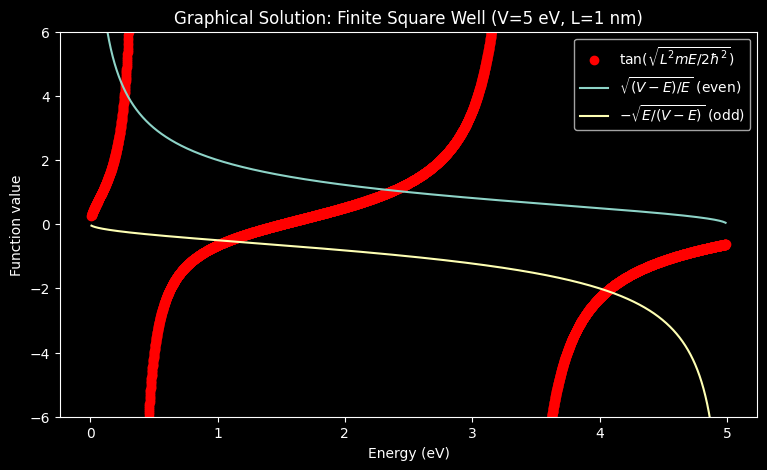

In [117]:
# Physical constants
m_e = 9.1094e-31       # electron mass in kg)

## THis is a Cool way the Guide call constants!!! I think its pretty neat

hbar = const.hbar         # reduced Planck constant (J s) ##
eV  = const.eV            # 1 eV in Joules
V0 = 5.0       
L  = 1e-9      


E_eV = np.linspace(0.01, V0 - 0.01, 5000) # (avoid exactly 0 and V0)
V  = E_eV * eV  # to Joules

tan_arg = np.tan(np.sqrt(L**2 * m_e * V / (2 * hbar**2)))

# Right-hand sides
rhs_even = np.sqrt((V0 - E_eV) / E_eV)
rhs_odd  = -np.sqrt(E_eV / (V0 - E_eV))

plt.figure(figsize=(9, 5))
# Scatter to avoid connecting discontinuities in tan
plt.scatter(E_eV, tan_arg, c='r',label=r'$\tan(\sqrt{L^2mE/2\hbar^2})$')
plt.plot(E_eV, rhs_even, label=r'$\sqrt{(V-E)/E}$ (even)')
plt.plot(E_eV, rhs_odd, label=r'$-\sqrt{E/(V-E)}$ (odd)')
plt.xlabel('Energy (eV)')
plt.ylabel('Function value')
plt.title('Graphical Solution: Finite Square Well (V=5 eV, L=1 nm)')
plt.legend()
plt.ylim(-6, 6)

plt.show()

#### 2. Analysis: 

*ANS:* The allowed energies are the  intersections curves. Approximately 4 allowed energies: about 2 for each, left and right. 

In [118]:
# 3. 

def well_even(E_eV):
    E_J = E_eV * eV
    arg = np.sqrt(L**2 * m_e * E_J / (2 * hbar**2))
    return np.tan(arg) - np.sqrt((V0 - E_eV) / E_eV)

def well_odd(E_eV):
    E_J = E_eV * eV
    arg = np.sqrt(L**2 * m_e * E_J / (2 * hbar**2))
    return np.tan(arg) + np.sqrt(E_eV / (V0 - E_eV))

# Initial guesses from the plot
guesses_even = [0.2, 2.4]
guesses_odd  = [1,4]

allowed_energies = []
for g in guesses_even:
    try:
        E_root = opt.newton(well_even, g)
        if 0 < E_root < V0:
            allowed_energies.append(('even', E_root))
    except Exception as e:
        print(f'Even guess {g} failed: {e}') # SOme previous interations give error for bar inital guesses, 
        # Hence this error message

print()
for g in guesses_odd:
    try:
        E_root = opt.newton(well_odd, g)
        if 0 < E_root < V0:
            allowed_energies.append(('odd', E_root))
    except Exception as e:
        print(f'Odd guess {g} failed: {e}')


print('Allowed energies (eV):')
for state, E in allowed_energies:
    print(f'  {state} state: E = {E:.4f} eV')



Allowed energies (eV):
  even state: E = 0.2718 eV
  even state: E = 2.3792 eV
  odd state: E = 1.0774 eV
  odd state: E = 4.0593 eV


## Task 5: 

Finding extrema of $f(x)$ is equivalent to finding roots of $f'(x) = 0$. Applying Newton-Raphson to this gives the update rule:

$$x_{i+1} = x_i - \frac{f'(x_i)}{f''(x_i)}$$

scipy.optimize provides several routines for minimizing scalar functions. Note: to **maximize** $g(x)$, minimize $-g(x)$.

The golden section search  method is the minimization analog of bisection: given a bracketing triplet $(a, b, c)$ with $a < b < c$ and $f(b) < f(a), f(c)$, it repeatedly contracts the bracket using the golden ratio to converge on the minimum.



#### 1. Analysis: 

From calculus: $f'(x) = 4.2x - 3.4 = 0 \implies x^* = 3.4/4.2 \approx 0.8095$

$f(x^*) = 2.1(0.8095)^2 - 3.4(0.8095) + 2.6 \approx 1.224$

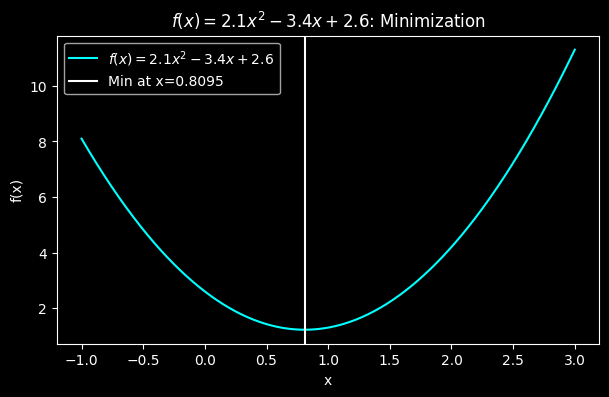

Calculus minimum: x* = 0.809524, f(x*) = 1.223810


In [119]:
def f_quad(x):
    return 2.1 * x**2 - 3.4 * x + 2.6

x_plot = np.linspace(-1, 3, 400)
plt.figure(figsize=(7, 4))
plt.plot(x_plot, f_quad(x_plot), color='cyan', label=r'$f(x)=2.1x^2-3.4x+2.6$')

x_min_calc = 3.4 / 4.2
plt.axvline(x_min_calc, label=f'Min at x={x_min_calc:.4f}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'$f(x) = 2.1x^2 - 3.4x + 2.6$: Minimization')
plt.legend()

plt.show()
print(f'Calculus minimum: x* = {x_min_calc:.6f}, f(x*) = {f_quad(x_min_calc):.6f}')

In [120]:
# 2.  


res_brent  = opt.minimize_scalar(f_quad, method='brent')
res_golden = opt.minimize_scalar(f_quad, method='golden')

print('Brent Method')
print(f'  x* = {res_brent.x:.8f}, f(x*) = {res_brent.fun:.8f}')
print(f'  Iterations: {res_brent.nit}')
print()

print('Golden')
print(f'  x* = {res_golden.x:.8f}, f(x*) = {res_golden.fun:.8f}')
print(f'  Iterations: {res_golden.nit}')

Brent Method
  x* = 0.80952381, f(x*) = 1.22380952
  Iterations: 5

Golden
  x* = 0.80952380, f(x*) = 1.22380952
  Iterations: 39


#### 3. Analysis: Brent vs. Golden

*ANS:* Both methods find the same exact minimum of 1.22380952. Brent's requires fewer iterations, (because it uses quadratic interpolation) golden's is the similar to bisection and converges at a fixed (slower) rate. 

In [121]:
#4. scipy.optimize.minimize with Default
res_minimize = opt.minimize(f_quad, x0=0.0)  # Initial guess x0=0
print(f'x* = {res_minimize.x[0]:.8f}')
print(f'f(x*) = {res_minimize.fun:.8f}')


x* = 0.80952380
f(x*) = 1.22380952


## Task 6: Landau Free Energy of Phase Transitions

### Background

Many systems undergo phase transitions as a parameter changes. For a ferromagnet, the bulk magnetization (the order parameter this is) spontaneously changes from zero above the critical temperature $T_c$ to nonzero below it;  a 2nd-order phase transition.

Landau's mean-field model gives the free energy in terms of the magnetization $M$:

$$F(M) = aM^2 + bM^4 - HM$$

where $a = a_0(T - T_c)$ changes sign at $T_c$, $b > 0$ is a positive constant, and $H$ is an external magnetic field.



#### 1. Analysis: 

$$F(M) = aM^2 + bM^4 - HM$$

where $a = a_0(T - T_c)$. Substitute that in:

$$F(M) = a_0(T - T_c)M^2 + bM^4 - HM$$

Now divide everything by $a_0 T_c$:

$$\frac{F(M)}{a_0 T_c} = \frac{a_0(T - T_c)}{a_0 T_c}M^2 + \frac{b}{a_0 T_c}M^4 - \frac{H}{a_0 T_c}M$$

Simplifing term by term

 $\frac{a_0(T - T_c)}{a_0 T_c} = \frac{T - T_c}{T_c} = \frac{T}{T_c} - 1 = t - 1$

$\frac{b}{a_0 T_c} = \tilde{b}$ (Given)

$\frac{H}{a_0 T_c} = \tilde{h}$

So,

$$\tilde{f}(M) = (t-1)M^2 + \tilde{b}M^4 - \tilde{h}M$$

I used Gemini For analysis becase I struggled with the plots in this section

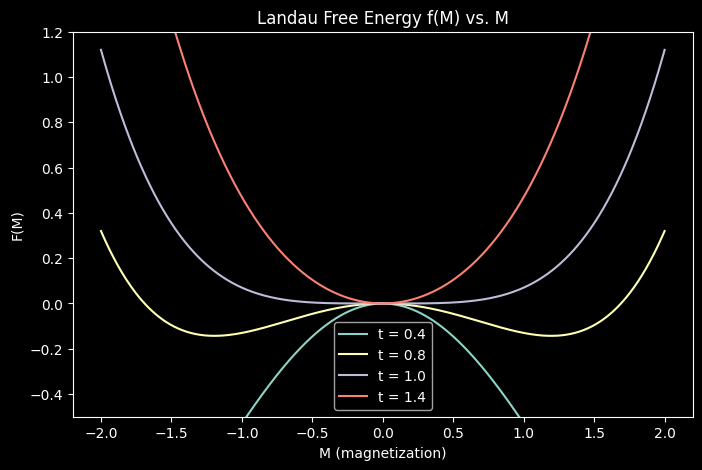

In [122]:
# 2. Plot 
def f_landau(M, t, b_ =0.07, h_ =0.0):
    return (t - 1) * M**2 + b_ * M**4 - h_ * M

M_arr = np.linspace(-2, 2, 800)

plt.figure(figsize=(8, 5))
for t_val in [0.4, 0.8, 1.0, 1.4]:
    plt.plot(M_arr, f_landau(M_arr, t_val), label=f't = {t_val}')

plt.ylim(-0.5, 1.2)
plt.xlabel('M (magnetization)')
plt.ylabel("F(M)")
plt.title('Landau Free Energy f(M) vs. M')
plt.legend()
plt.show()

#### 3. Analysis: Shape vs Temperature

*ANS:* Below Tc (t < 1) theres a double-well shape with two dips at nonzero M, the magnet wants to be magnetized. At Tc (t = 1) the bottom flattens out. Above Tc (t > 1) theres only one minimum at M = 0, no magnetization. The shape changing from double to single well is what drives the phase transition.

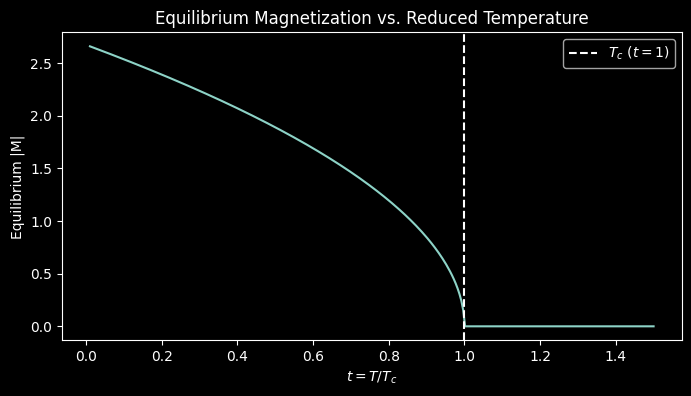

In [123]:
# 4. Equilibrium Magnetization vs Temperature
t_arr = np.linspace(0.01, 1.5, 300)
M_eq = []
for t_val in t_arr:
    def neg_f(M):
        return f_landau(M[0], t_val)
    x0 = [0.5] if t_val < 1 else [0.0]
    res = opt.minimize(neg_f, x0)
    M_eq.append(abs(res.x[0]))

plt.figure(figsize=(8, 4))
plt.plot(t_arr, M_eq)
plt.axvline(1.0, ls='--', label=r'$T_c$ ($t=1$)')
plt.xlabel(r'$t = T/T_c$')
plt.ylabel('Equilibrium |M|')
plt.title('Equilibrium Magnetization vs. Reduced Temperature')
plt.legend()
plt.show()

#### 5. Analysis: Is This a 2nd-Order Phase Transition?

*ANS:* Yes. |M| goes to zero smoothly as t approaches 1, no sudden jump. But the slope changes suddenly at t = 1. Thats the definition of a 2nd-order (continuous) phase transition.

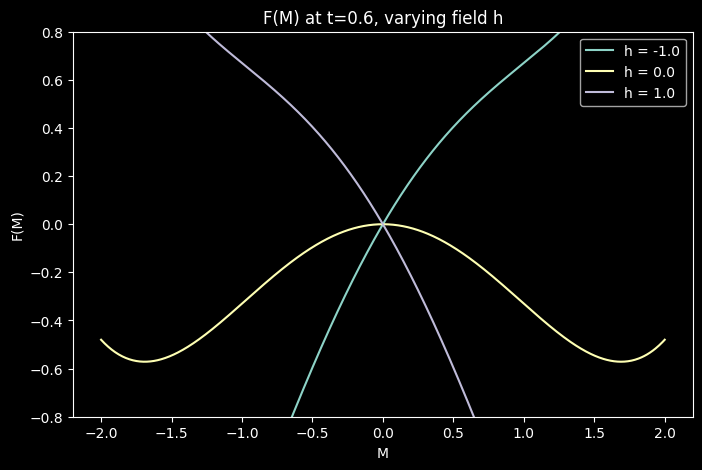

In [124]:
# 6. F(M) at different external fields
h_vals = [-1.0, 0.0, 1.0]

plt.figure(figsize=(8, 5))
for h_val in h_vals:
    plt.plot(M_arr, f_landau(M_arr, 0.6, h_=h_val), label=f'h = {h_val}')

plt.ylim(-0.8, 0.8)
plt.xlabel('M')
plt.ylabel('F(M)')
plt.title('F(M) at t=0.6, varying field h')
plt.legend()
plt.show()

#### 7. Analysis: Hysteresis

*ANS:* With h = 0, theres two symmetric minima. When you turn on a positive field, one side gets lower than the other. The system gets stuck in whichever minimum it was already in, so sweeping the field back and forth gives different paths. Thats hysteresis, like a fridge magnet keeping its magnetization.

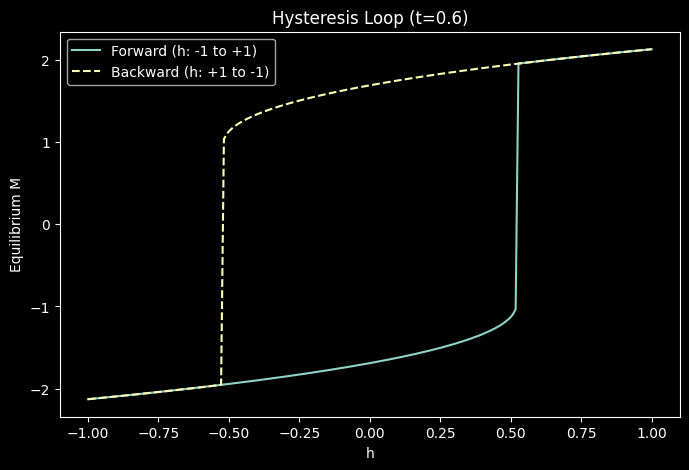

In [125]:
# 8. Hysteresis Loop
h_sweep = np.linspace(-1.0, 1.0, 200)
M_forward, M_backward = [], []

# Forward sweep: h from -1 to +1
M0 = -1.0
for h_val in h_sweep:
    def ff(M): return f_landau(M[0], 0.6, h_=h_val)
    res = opt.minimize(ff, [M0])
    M0 = res.x[0]
    M_forward.append(M0)

# Backward sweep: h from +1 to -1
M0 = M_forward[-1]
for h_val in reversed(h_sweep):
    def ff(M): return f_landau(M[0], 0.6, h_=h_val)
    res = opt.minimize(ff, [M0])
    M0 = res.x[0]
    M_backward.append(M0)
M_backward = M_backward[::-1]

plt.figure(figsize=(8, 5))
plt.plot(h_sweep, M_forward, label='Forward (h: -1 to +1)')
plt.plot(h_sweep, M_backward, ls='--', label='Backward (h: +1 to -1)')
plt.xlabel('h')
plt.ylabel('Equilibrium M')
plt.title('Hysteresis Loop (t=0.6)')
plt.legend()
plt.show()

#### 9. Analysis: Hysteresis Loop

*ANS:* Classic hysteresis loop. On the forward sweep M stays negative even after h turns positive, then jumps up. Backward sweep does the opposite. The system has memory because below Tc theres two stable states, and it stays in whichever one it started in until the field is strong enough to force it out.

## Task 7: Optimal Operating Temperature for a Lightbulb

### Background

All objects at thermal equilibrium emit light according to **Planck's law**:

$$I(\lambda, T) = \frac{2\pi A h c^2 \lambda^{-5}}{e^{hc/(\lambda k_B T)} - 1}$$

Visible light: $\lambda_1 = 390$ nm (violet) to $\lambda_2 = 750$ nm (red).

After a variable substitution $x = hc/(\lambda k_B T)$, the efficiency of visible light emission (fraction of total radiated power in the visible range) is:

$$\eta(T) = \frac{15}{\pi^4} \int_{hc/(\lambda_2 k_B T)}^{hc/(\lambda_1 k_B T)} \frac{x^3}{e^x - 1}\, dx$$

In [126]:

# 1. 
h_p  = const.h       
c_l  = const.c  # speed of light
k_B  = const.k       

lam1 = 390e-9  #  nm (violet)
lam2 = 750e-9  # nm (red)

def integrand(x):
    return x**3 / (np.exp(x) - 1)

def n(T):

    x_lo = h_p * c_l / (lam2 * k_B * T)  # lower limit (red end)
    x_hi = h_p * c_l / (lam1 * k_B * T)  # upper limit (violet end)
    integral, _ = quad(integrand, x_lo, x_hi) # Quad
    return (15 / np.pi**4) * integral

print(f'n(3000 K) = {n(3000):.6f}')
print(f'n(6000 K) = {n(6000):.6f}')

n(3000 K) = 0.108628
n(6000 K) = 0.436301


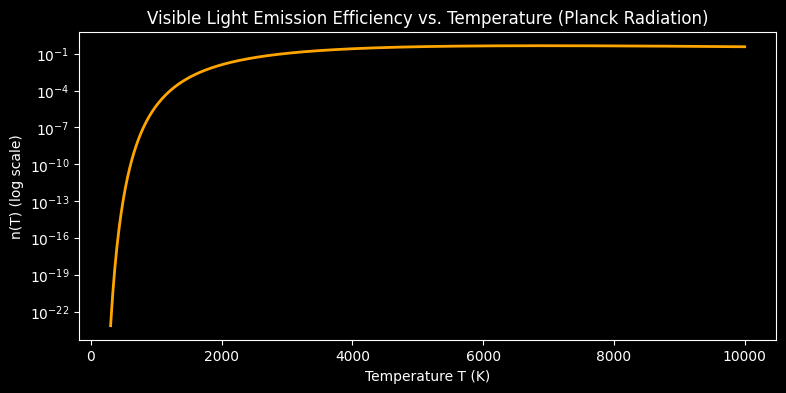

In [127]:

# 2. Plot 
T_arr  = np.linspace(300, 10000, 300)
n_arr = np.array([n(T) for T in T_arr])

plt.figure(figsize=(9, 4))
plt.plot(T_arr, n_arr, color='orange', lw=2)
plt.xlabel('Temperature T (K)')
plt.ylabel('n(T) (log scale)')
plt.title('Visible Light Emission Efficiency vs. Temperature (Planck Radiation)')
plt.yscale('log')

plt.show()


#### 3. Analysis: Estimate Optimal Temperature

ANS: From the plot, the plot seems to reach a maximum n(T) at about 5000K, the effeciency is aorud $10^{-1}$

In [128]:
# 4.

# Maximize n(T) = minimize -n(T)
def neg_n(T_arr):
    return -n(T_arr[0])

res_max_n = opt.minimize(neg_n, x0=[6000.0], bounds=[(3000, 7000)])
T_opt  = res_max_n.x[0]
n_opt = n(T_opt)
print(f'Optimal temperature: T* = {T_opt:.1f} K')
print(f'Maximum efficiency:  n* = {n_opt:.6f} = {100*n_opt:.4f}%')

Optimal temperature: T* = 6000.0 K
Maximum efficiency:  n* = 0.436301 = 43.6301%


#### 5. Melting Temperature of Tungsten

The melting temperature of tungsten is approximately 3695 K. This is why tungsten is used as the filament material in incandescent lightbulbs.


#### 6. Analysis: Optimal Temperature vs. Practical Constraints

*ANS:* The optimal temperature for maximum visible-light efficiency ($\approx 6000$ K) far higher than the melting point of tungsten (3695 K). The filament would just melt.

But from the plot, the effeciency does not seem to be that off from, still the same *10^-1*

## Task 8: Wrap Up

### 1. Feedback on Wording

I did not feel very connetected to the Quantum Particle Question, it seemed relevent but wasnt able to fully understand what is happening, like the physics part
### 2. Additional Comments
I Found this Guide to be very long